In [ ]:
import json
import csv
import cv2
import numpy as np
import random
import datetime
import matplotlib.pyplot as plt

# Create task

In [3]:
data = []
for type in ["train","test"]:
    csv_file = open(f"../../emoticon-data/emotic/annots_arrs/annot_arrs_{type}.csv", "r")
    reader = csv.DictReader(csv_file, delimiter=",")
    data.extend(row for row in reader)
    csv_file.close()
len(data)

31918

(array([  115.,   268.,   697.,  2440.,  7698., 10830.,  5496.,  3547.,
          617.,   210.]),
 array([ 1. ,  1.9,  2.8,  3.7,  4.6,  5.5,  6.4,  7.3,  8.2,  9.1, 10. ]),
 <BarContainer object of 10 artists>)

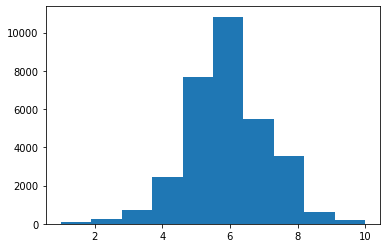

In [372]:
plt.hist([float(row['Valence']) for row in data], 10)

In [373]:
dims=["Valence","Arousal","Dominance"]
categories=["Peace","Affection","Esteem","Anticipation","Engagement","Confidence","Happiness","Pleasure",
      "Excitement","Surprise","Sympathy","Doubt/Confusion","Disconnection","Fatigue","Embarrassment",
      "Yearning","Disapproval","Aversion","Annoyance","Anger","Sensitivity","Sadness","Disquietment","Fear","Pain","Suffering"]

# Fix resolution

In [374]:
tofix = set([row['Arr_name'] for row in data if float(row['X_max'])>float(row['Width'])+1 or float(row['Y_max'])>float(row['Height'])+1])
for entry in data:
    if entry['Arr_name'] in tofix:
        entry['Width'], entry['Height'] = entry['Height'], entry['Width']

In [375]:
toremove = set([row['Arr_name'] for row in data if float(row['X_max'])>float(row['Width'])+1 
                or float(row['Y_max'])>float(row['Height'])+1])
data = [row for row in data if row['Arr_name'] not in toremove]
len(data)

31544

# Publish

In [392]:
published = ['crop_arr_train_17022.npy', 'crop_arr_train_9210.npy', 'crop_arr_test_3959.npy']
#['img_arr_12293', 'img_arr_21157', 'img_arr_6662']

In [393]:
data2 = [row | {"published":True} for row in data if row['Crop_name'] in published]
len(data2)

3

In [405]:
def coverage(row):
    return (float(row['X_max'])-float(row['X_min']))* \
    (float(row['Y_max'])-float(row['Y_min']))/ \
    float(row['Width'])/float(row['Height'])
data3 = np.random.choice(
    [row for row in data if coverage(row)>0.2], 200)

In [409]:
selection = [
    {
        **entry,
        "file": "emotic/images/"+entry['Arr_name'].replace('.npy','.jpg'),
        "X_min": int(float(entry["X_min"])),
        "X_max": int(float(entry["X_max"])),
        "Y_min": int(float(entry["Y_min"])),
        "Y_max": int(float(entry["Y_max"])),
        "Width": int(float(entry["Width"])),
        "Height": int(float(entry["Height"])),
    } | {
        key : float(entry[key]) for key in dims
    }
    for entry in data2 + data3.tolist()]
len(selection)

203

In [410]:
id = "encode-"+datetime.datetime.now().isoformat()
print(f"Writing task definition for {id}")
with open("gen/work.json", "w") as file:
    json.dump({
        "id": id,
        "data": selection
    }, file, indent=2)

Writing task definition for encode-2022-01-30T10:21:05.284680


In [411]:
selection[0]

{'Filename': 'COCO_train2014_000000035358.jpg',
 'Width': 640,
 'Height': 480,
 'Age': 'Kid',
 'Gender': 'Male',
 'Valence': 6.0,
 'Arousal': 5.0,
 'Dominance': 3.0,
 'Peace': '0.0',
 'Affection': '0.0',
 'Esteem': '0.0',
 'Anticipation': '0.0',
 'Engagement': '1.0',
 'Confidence': '0.0',
 'Happiness': '0.0',
 'Pleasure': '1.0',
 'Excitement': '1.0',
 'Surprise': '0.0',
 'Sympathy': '0.0',
 'Doubt/Confusion': '0.0',
 'Disconnection': '0.0',
 'Fatigue': '0.0',
 'Embarrassment': '0.0',
 'Yearning': '0.0',
 'Disapproval': '0.0',
 'Aversion': '0.0',
 'Annoyance': '0.0',
 'Anger': '0.0',
 'Sensitivity': '0.0',
 'Sadness': '0.0',
 'Disquietment': '0.0',
 'Fear': '0.0',
 'Pain': '0.0',
 'Suffering': '0.0',
 'X_min': 248,
 'Y_min': 112,
 'X_max': 452,
 'Y_max': 271,
 'Arr_name': 'img_arr_6662.npy',
 'Crop_name': 'crop_arr_train_9210.npy',
 'published': True,
 'file': 'emotic/images/img_arr_6662.jpg'}

# Search for image

In [298]:
import os
files = os.listdir('../../emoticon-data/emotic/images')
len(files)

23172

In [299]:
img0 = cv2.imread('100000000000019D000000F6FB947CA046C38FFE.jpg')
img0 = np.array(cv2.resize(img0, (224,224)), dtype='float')

error: OpenCV(4.5.4) /tmp/opencv-20220113-47010-rzspee/opencv-4.5.4/modules/imgproc/src/resize.cpp:4051: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [281]:
mindist = 1000000
best = None
for file in files:
    if ".jpg" in file:
        img1 = cv2.imread('../../emoticon-data/emotic/images/' + file)
        dist = np.linalg.norm(img0 - img1)
        if dist < mindist:
            best = file
            mindist = dist
            print(f"{dist} {best}")

38016.133075314225 img_arr_22825.jpg
32489.43266663793 img_arr_13420.jpg
30249.79910677094 img_arr_8950.jpg
29038.90641880303 img_arr_14373.jpg
28662.916774117737 img_arr_13385.jpg
27739.843564807645 img_arr_2266.jpg
27517.107297097926 img_arr_8213.jpg
26210.9054021413 img_arr_21444.jpg
26161.381691340386 img_arr_2477.jpg
25986.4913560873 img_arr_14412.jpg
25641.171619097284 img_arr_16507.jpg
23739.975105294445 img_arr_6662.jpg
